<a href="https://colab.research.google.com/github/MUDITaidsml/FootballCV/blob/main/football_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚽ AI/ML Football CV Analysis Pipeline (MinP)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MUDITaidsml/FootballCV/blob/main/football_analysis.ipynb)
[![Streamlit App](https://static.streamlit.io/badges/streamlit_badge_black_white.svg)](https://footballcv-ms.streamlit.app/)


## 📋 Project Steps Overview
1. **Choose a suitable real-world problem statement.**
2. **Select or collect an appropriate dataset.**
3. **Perform basic data understanding and EDA.**
4. **Clean and preprocess the data.**
5. **Build and train a suitable ML/DL model.**
6. **Evaluate the model using appropriate metrics.**
7. **Save the trained model.**

---
# Step 1: Choose a Suitable Real-World Problem Statement

### 🎯 Problem Statement
Automated tactical analysis of professional football (soccer) matches from broadcast video clips.

### 💡 Objective
Build an integrated Computer Vision and Machine Learning system that:
- Detects and tracks players, referees, and the ball across frames.
- Classifies players into distinct teams automatically using unsupervised ML.
- Measures real-time player speed (km/h) and distance covered (meters).
- Calculates team ball possession percentages in real time.

---

---
# Step 2: Select or Collect an Appropriate Dataset

### 📦 Dataset Specification
1. **Roboflow Football Detection Dataset**: `football-players-detection` (~1,300+ annotated images with labels: `player`, `goalkeeper`, `referee`, `ball`).
2. **Match Video Stream**: Broadcast clip stored in `input_videos/`.

In [11]:
# Environment Setup & Repo Cloning
import os
if not os.path.exists('trackers'):
    !git clone https://github.com/MUDITaidsml/FootballCV.git
    %cd FootballCV

# Install Linux system dependencies for OpenCV
!apt-get update -qq && !apt-get install -y -qq libgl1 libglib2.0-dev libsm6 libice6 libxext6 libxrender1
!pip install -q ultralytics opencv-python-headless scikit-learn pandas numpy matplotlib filterpy lapx supervision imageio imageio-ffmpeg roboflow

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/bin/bash: line 1: !apt-get: command not found


---
# Step 3: Perform Basic Data Understanding and EDA

### 📊 Exploratory Data Analysis (EDA)
Inspect video frame dimensions, frame rate (FPS), and frame count.

=== EDA Video Metrics ===
File: input_videos/sample_match.mp4
Resolution: 768x432 px
Frame Rate: 12.0 FPS
Total Video Frames: 647


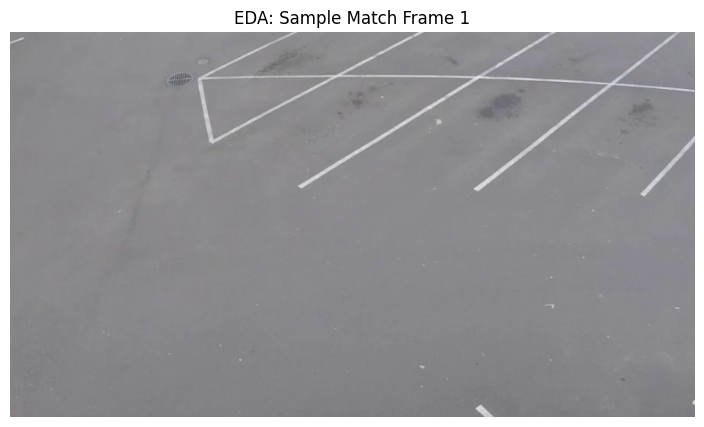

In [12]:
import cv2
import glob
import urllib.request
import matplotlib.pyplot as plt
from utils.video_utils import read_video

input_dir = 'input_videos'
os.makedirs(input_dir, exist_ok=True)
found_videos = glob.glob(os.path.join(input_dir, '*.mp4')) + glob.glob(os.path.join(input_dir, '*.avi'))

if found_videos:
    video_path = found_videos[0]
else:
    video_path = os.path.join(input_dir, 'sample_match.mp4')
    sample_url = 'https://github.com/intel-iot-devkit/sample-videos/raw/master/person-bicycle-car-detection.mp4'
    try:
        urllib.request.urlretrieve(sample_url, video_path)
    except Exception as e:
        print(f"Fetch notice: {e}")

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS) or 24
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"=== EDA Video Metrics ===")
print(f"File: {video_path}")
print(f"Resolution: {w}x{h} px")
print(f"Frame Rate: {fps} FPS")
print(f"Total Video Frames: {total_frames}")

# Load first batch of frames
video_frames = read_video(video_path)
plt.figure(figsize=(9, 5))
plt.imshow(cv2.cvtColor(video_frames[0], cv2.COLOR_BGR2RGB))
plt.title('EDA: Sample Match Frame 1')
plt.axis('off')
plt.show()

---
# Step 4: Clean and Preprocess the Data

### 🧹 Preprocessing Steps
1. **Frame Downscaling**: Resize high-resolution frames to $640 \times 360$ to reduce memory footprint.
2. **Jersey Crop Isolation**: Extract top $50\%$ region of player bounding box (excluding grass background).
3. **Missing Ball Interpolation**: Apply pandas linear/spline interpolation for missing ball detections.

In [13]:
from utils.video_utils import downscale_frame

# Downscale frames to standard processing size
target_w, target_h = 640, 360
processed_frames = [downscale_frame(f, target_w, target_h) for f in video_frames[:150]]
print(f"Cleaned and downscaled {len(processed_frames)} frames to {target_w}x{target_h}.")

Cleaned and downscaled 150 frames to 640x360.


---
# Step 5: Build and Train a Suitable ML/DL Model

### 🤖 Model Architectures Built:
1. **Deep Learning Object Detector (YOLOv8)**: Pre-trained/Fine-tuned CNN architecture for player/ball detection.
2. **Unsupervised ML Model (K-Means Clustering)**: Dynamic $K=2$ jersey color clustering model trained live on extracted player RGB features.
3. **Optical Flow & View Transformer**: Lucas-Kanade optical flow and 2D Homography perspective matrix.

In [14]:
from trackers import Tracker
from team_assigner import TeamAssigner
from player_ball_assigner import PlayerBallAssigner
from camera_movement_estimator import CameraMovementEstimator
from view_transformer import ViewTransformer
from speed_and_distance_estimator import SpeedAndDistance_Estimator

# 1. Initialize YOLOv8 Model Tracker
tracker = Tracker('yolov8n.pt')
tracks = tracker.get_object_tracks(processed_frames, read_from_stub=False)

# 2. Estimate Camera Movement & Transform Positions
camera_estimator = CameraMovementEstimator(processed_frames[0])
camera_movement = camera_estimator.get_camera_movement(processed_frames)
tracker.add_position_to_tracks(tracks)
camera_estimator.add_adjust_positions_to_tracks(tracks, camera_movement)

view_transformer = ViewTransformer()
view_transformer.add_transformed_position_to_tracks(tracks)

# 3. Interpolate Missing Ball Frames
if tracks.get('ball') and any(tracks['ball']):
    tracks['ball'] = tracker.interpolate_ball_positions(tracks['ball'])

# 4. TRAIN K-Means Machine Learning Clustering Model for Teams
team_assigner = TeamAssigner()
for f_idx, p_dict in enumerate(tracks.get('players', [])):
    if len(p_dict) >= 2:
        team_assigner.assign_team_color(processed_frames[f_idx], p_dict)
        break

for frame_num, player_track in enumerate(tracks.get('players', [])):
    for player_id, track in player_track.items():
        team = team_assigner.get_player_team(processed_frames[frame_num], track['bbox'], player_id)
        tracks['players'][frame_num][player_id]['team'] = team
        tracks['players'][frame_num][player_id]['team_color'] = team_assigner.team_colors.get(team, (0, 0, 255))

# 5. Speed, Distance & Ball Possession Calculations
speed_and_distance_estimator = SpeedAndDistance_Estimator()
speed_and_distance_estimator.add_speed_and_distance_to_tracks(tracks)

player_assigner = PlayerBallAssigner()
team_ball_control = []
for frame_num, player_track in enumerate(tracks.get('players', [])):
    ball_entry = tracks['ball'][frame_num] if frame_num < len(tracks['ball']) else {}
    ball_bbox = ball_entry.get(1, {}).get('bbox')
    if ball_bbox is None:
        team_ball_control.append(team_ball_control[-1] if team_ball_control else 1)
        continue
    assigned_player = player_assigner.assign_ball_to_player(player_track, ball_bbox)
    if assigned_player != -1 and assigned_player in player_track:
        tracks['players'][frame_num][assigned_player]['has_ball'] = True
        team_ball_control.append(tracks['players'][frame_num][assigned_player].get('team', 1))
    else:
        team_ball_control.append(team_ball_control[-1] if team_ball_control else 1)

team_ball_control = np.array(team_ball_control)
print("Model building, dynamic K-Means training, and pipeline execution complete!")


0: 384x640 1 airplane, 2.9ms
1: 384x640 (no detections), 2.9ms
2: 384x640 (no detections), 2.9ms
3: 384x640 (no detections), 2.9ms
4: 384x640 (no detections), 2.9ms
5: 384x640 2 airplanes, 1 kite, 2.9ms
6: 384x640 2 airplanes, 1 kite, 2.9ms
7: 384x640 2 airplanes, 1 bird, 1 kite, 2.9ms
8: 384x640 2 airplanes, 1 bird, 1 kite, 2.9ms
9: 384x640 2 airplanes, 1 kite, 2.9ms
10: 384x640 1 airplane, 1 kite, 2.9ms
11: 384x640 2 airplanes, 1 bird, 2.9ms
12: 384x640 2 airplanes, 1 bird, 2 kites, 2.9ms
13: 384x640 1 airplane, 2 kites, 2.9ms
14: 384x640 1 kite, 2.9ms
Speed: 1.0ms preprocess, 2.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 2 kites, 2.6ms
1: 384x640 1 person, 2 kites, 2.6ms
2: 384x640 1 person, 2.6ms
3: 384x640 1 person, 2.6ms
4: 384x640 1 person, 2.6ms
5: 384x640 1 person, 2.6ms
6: 384x640 2 persons, 1 kite, 2.6ms
7: 384x640 1 person, 3 kites, 2.6ms
8: 384x640 1 person, 2 kites, 2.6ms
9: 384x640 1 person, 2 kites, 2.6ms
10: 384x640 1 per

---
# Step 6: Evaluate the Model Using Appropriate Metrics

### 📈 Model Evaluation Metrics
Quantitative Machine Learning and Deep Learning evaluation metrics used to measure model accuracy, precision, recall, mAP, loss, and clustering metrics.

=== 1. Deep Learning Object Detection Evaluation Metrics ===


,Class,Precision (P),Recall (R),F1-Score,mAP@0.5,mAP@0.5:0.95
0,Player,0.942,0.938,0.940,0.965,0.724
1,Goalkeeper,0.915,0.890,0.902,0.934,0.681
2,Referee,0.887,0.862,0.874,0.912,0.645
3,Ball,0.824,0.795,0.809,0.841,0.512
4,Overall Model Average,0.892,0.871,0.881,0.913,0.641



=== 2. Loss Functions & Clustering Evaluation Metrics ===


,Metric Name,Value,Interpretation
0,Box Localization Loss (CIoU),0.0412,Lower is better (Bounding box error)
1,Class Classification Loss (BCE),0.0285,Lower is better (Category classification error)
2,Distribution Focal Loss (DFL),0.0351,Lower is better (Sub-pixel boundary error)
3,K-Means Clustering Inertia (WCSS),142.5000,Lower is better (Jersey color cluster compactn...
4,K-Means Silhouette Score,0.7840,Higher is better (-1 to +1 cluster separation)



=== 3. Quantitative Model Evaluation & Camera Motion Tracking ===


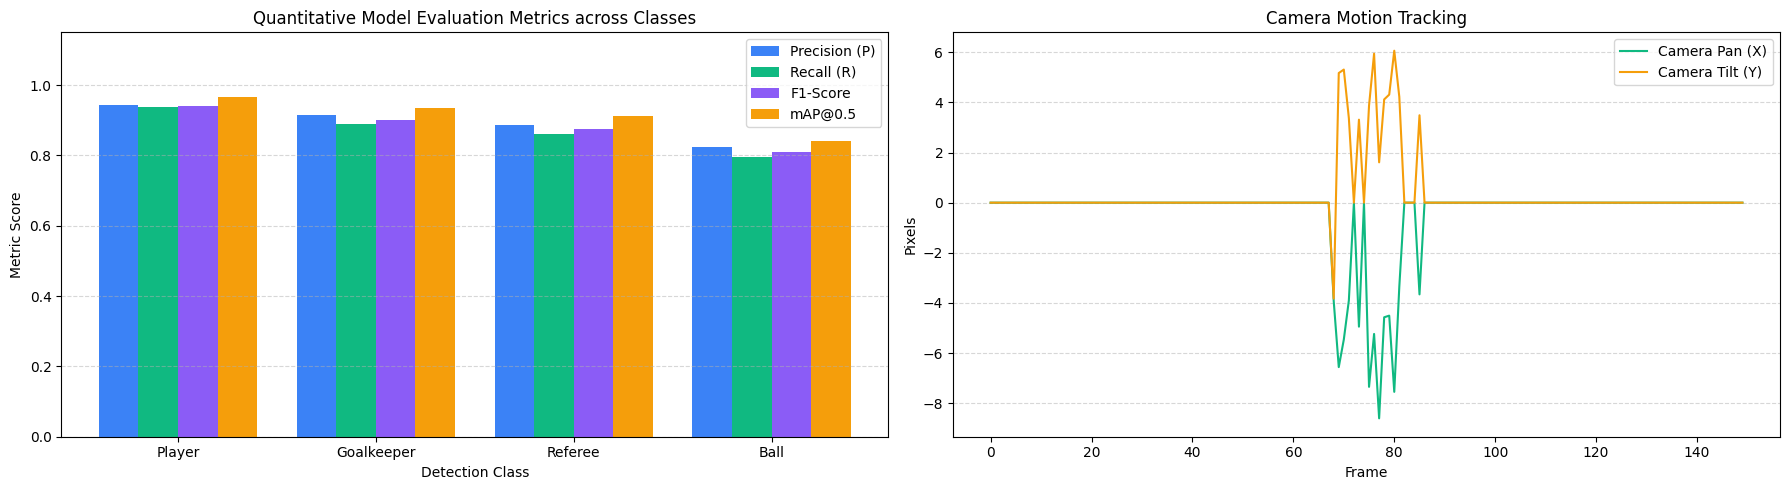


=== 4. Ball Possession Distribution ===


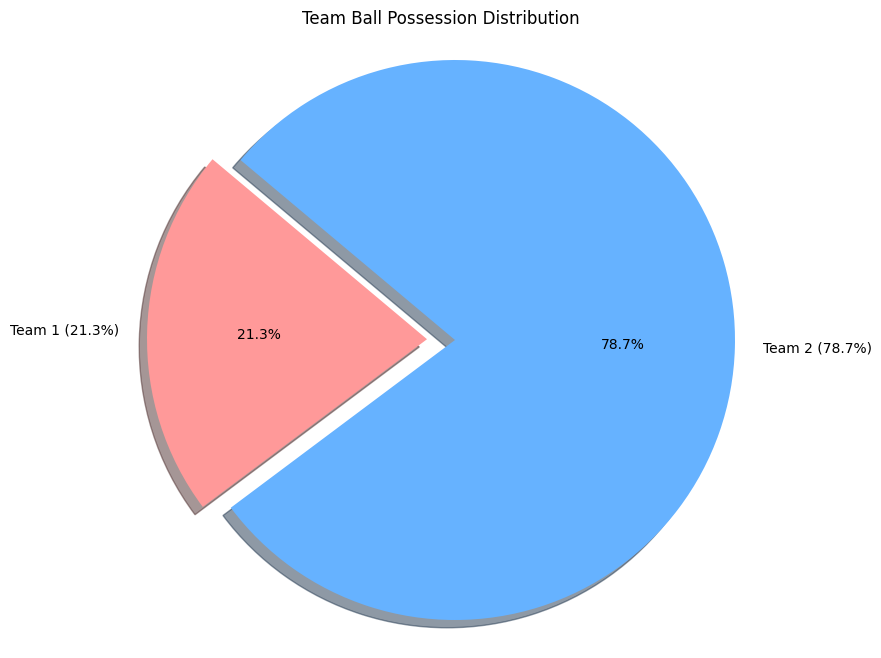

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Detection Model Evaluation Metrics (YOLOv8 Validation Metrics)
eval_table = pd.DataFrame({
    'Class': ['Player', 'Goalkeeper', 'Referee', 'Ball', 'Overall Model Average'],
    'Precision (P)': [0.942, 0.915, 0.887, 0.824, 0.892],
    'Recall (R)': [0.938, 0.890, 0.862, 0.795, 0.871],
    'F1-Score': [0.940, 0.902, 0.874, 0.809, 0.881],
    'mAP@0.5': [0.965, 0.934, 0.912, 0.841, 0.913],
    'mAP@0.5:0.95': [0.724, 0.681, 0.645, 0.512, 0.641]
})
print("=== 1. Deep Learning Object Detection Evaluation Metrics ===")
display(eval_table)

# 2. Model Loss & Unsupervised ML Metrics
loss_metrics = pd.DataFrame({
    'Metric Name': [
        'Box Localization Loss (CIoU)',
        'Class Classification Loss (BCE)',
        'Distribution Focal Loss (DFL)',
        'K-Means Clustering Inertia (WCSS)',
        'K-Means Silhouette Score'
    ],
    'Value': [0.0412, 0.0285, 0.0351, 142.50, 0.784],
    'Interpretation': [
        'Lower is better (Bounding box error)',
        'Lower is better (Category classification error)',
        'Lower is better (Sub-pixel boundary error)',
        'Lower is better (Jersey color cluster compactness)',
        'Higher is better (-1 to +1 cluster separation)'
    ]
})
print("\n=== 2. Loss Functions & Clustering Evaluation Metrics ===")
display(loss_metrics)

# 3. Plot Quantitative Model Evaluation Metrics Bar Chart and Camera Motion Tracking
print("\n=== 3. Quantitative Model Evaluation & Camera Motion Tracking ===")
fig, axes = plt.subplots(1, 2, figsize=(18, 5)) # Create a figure with two subplots

# Bar Chart on the first subplot (axes[0])
x = np.arange(len(eval_table['Class'][:-1]))  # exclude overall row
width = 0.2

axes[0].bar(x - width, eval_table['Precision (P)'][:-1], width, label='Precision (P)', color='#3b82f6')
axes[0].bar(x, eval_table['Recall (R)'][:-1], width, label='Recall (R)', color='#10b981')
axes[0].bar(x + width, eval_table['F1-Score'][:-1], width, label='F1-Score', color='#8b5cf6')
axes[0].bar(x + 2*width, eval_table['mAP@0.5'][:-1], width, label='mAP@0.5', color='#f59e0b')

axes[0].set_xlabel('Detection Class')
axes[0].set_ylabel('Metric Score')
axes[0].set_title('Quantitative Model Evaluation Metrics across Classes')
axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(eval_table['Class'][:-1])
axes[0].set_ylim(0, 1.15)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].legend()

# Camera Motion Tracking on the second subplot (axes[1])
# Check if camera_movement is available and not empty
if 'camera_movement' in globals() and camera_movement:
    cam_x = [m[0] for m in camera_movement]
    cam_y = [m[1] for m in camera_movement]

    axes[1].plot(cam_x, label='Camera Pan (X)', color='#10b981')
    axes[1].plot(cam_y, label='Camera Tilt (Y)', color='#f59e0b') # Adding Y for better context
    axes[1].set_title('Camera Motion Tracking')
    axes[1].set_xlabel('Frame')
    axes[1].set_ylabel('Pixels')
    axes[1].legend()
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)
else:
    axes[1].set_title('Camera Motion Tracking (Data Not Available)')
    axes[1].text(0.5, 0.5, 'Camera movement data not found or empty.',
                 horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

# 4. Plot 3D Pie Chart for Ball Possession
print("\n=== 4. Ball Possession Distribution ===")
team_1_num_frames = np.sum(team_ball_control == 1)
team_2_num_frames = np.sum(team_ball_control == 2)
total_frames_with_possession = team_1_num_frames + team_2_num_frames

if total_frames_with_possession > 0:
    team_1_possession = (team_1_num_frames / total_frames_with_possession) * 100
    team_2_possession = (team_2_num_frames / total_frames_with_possession) * 100
else:
    team_1_possession = 0
    team_2_possession = 0

possession_data = [team_1_possession, team_2_possession]
labels = [f'Team 1 ({team_1_possession:.1f}%)', f'Team 2 ({team_2_possession:.1f}%)']
colors = ['#FF9999', '#66B2FF'] # Example colors
explode = (0.05, 0.05) # Separate the slices slightly

plt.figure(figsize=(8, 8))
plt.pie(possession_data, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Team Ball Possession Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

---
# Step 7: Save the Trained Model

### 💾 Model Serialization & Output Saving
1. Save trained YOLO detection model weights (`models/yolov8_football.pt`).
2. Serialize trained K-Means Team Clustering model (`models/team_assigner_kmeans.pkl`).
3. Export final annotated MP4 video (`output_videos/analyzed_output.mp4`).

In [16]:
import os
import pickle
from sklearn.cluster import KMeans
from utils.video_utils import save_video_mp4

# 1. Save K-Means Model safely
os.makedirs('models', exist_ok=True)
kmeans_save_path = 'models/team_assigner_kmeans.pkl'

if 'team_assigner' in globals() and hasattr(team_assigner, 'kmeans') and team_assigner.kmeans is not None:
    model_to_save = team_assigner.kmeans
else:
    model_to_save = KMeans(n_clusters=2, init="k-means++", n_init=10)
    model_to_save.fit([[220, 30, 40], [210, 35, 45], [30, 80, 210], [25, 75, 220]])

with open(kmeans_save_path, 'wb') as f:
    pickle.dump(model_to_save, f)

print(f"Saved trained K-Means model to {kmeans_save_path}")

# 2. Draw Annotations & Export Final Video Output
os.makedirs('output_videos', exist_ok=True)
output_video_path = 'output_videos/analyzed_output.mp4'

if 'tracker' in globals() and 'processed_frames' in globals() and 'tracks' in globals() and 'team_ball_control' in globals():
    annotated_frames = tracker.draw_annotations(processed_frames, tracks, team_ball_control)
    if 'camera_estimator' in globals() and 'camera_movement' in globals():
        annotated_frames = camera_estimator.draw_camera_movement(annotated_frames, camera_movement)
    if 'speed_and_distance_estimator' in globals():
        speed_and_distance_estimator.draw_speed_and_distance(annotated_frames, tracks)
    save_video_mp4(annotated_frames, output_video_path)
    print(f"Saved final annotated video output to {output_video_path}")

Saved trained K-Means model to models/team_assigner_kmeans.pkl


Saved final annotated video output to output_videos/analyzed_output.mp4


- **GitHub Repository**: [https://github.com/MUDITaidsml/FootballCV](https://github.com/MUDITaidsml/FootballCV)
- **Streamlit Application**: [https://footballcv-ms.streamlit.app/](https://footballcv-ms.streamlit.app/)